In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from PIL import Image
import os .path
import os
import matplotlib.image as mpimg


In [4]:
x=[]
def load_images(path, classes):
    for fol in classes:
        seq=os.listdir(path+u'/'+fol)
        for img in seq:
#             if(img=='T2w'):
                imgg=img
                im=os.listdir(path+u'/'+fol+u'/'+imgg)
                for mri in im:
                    pat=path+u'/'+fol+u'/'+imgg+u'/'+mri
                    fimg=mpimg.imread(pat);
                    x.append(fimg)
    print(len(x))
    return x

In [5]:
path1 = "/kaggle/input/rsna-final-36-v14/Patients_New36/Patients_New36"
path2 = "/kaggle/input/rsna-final-36-v14/train4/train4"
path3 = "/kaggle/input/rsna-final-36-v14/train4_version3/train4_version3"
path4 = "/kaggle/input/rsna-final-36-v14/Dataset_Four(36_Patients)/Dataset_Four(36_Patients)"

classes = os.listdir(path1) 
classes2= os.listdir(path2)  
classes3= os.listdir(path3)
classes4= os.listdir(path4)

images = load_images(path1, classes) 
images = load_images(path2, classes2)  
# images=  load_images(path3, classes3)
# images=  load_images(path4, classes4)
images = np.array(images)  # Convert the list of images to a NumPy array


# Now you can access the shape of the images array
print(images.shape)
x=images
# 116 Patients

4884
14674
(14674, 256, 256)


In [6]:
def split_and_normalize_data(x):
    """
    Shuffles the input data array and splits it into training and testing sets.
    
    Parameters:
        x (numpy.ndarray): The input data array.

    Returns:
        tuple: A tuple containing the shuffled training and testing data arrays.
    """
    n = x.shape[0]
    randomize = np.arange(n)
    np.random.shuffle(randomize)
    x = x[randomize]
    test_split = round(n * 8 / 10)
    x_train = x[:test_split]
    x_test = x[test_split:]
    
    x_train = x[:test_split].astype('float32') / 255
    x_test = x[test_split:].astype('float32') / 255

    return x_train, x_test

In [7]:
x_train, x_test =split_and_normalize_data(x)

In [8]:
print(x_train.shape)
print(x_test.shape)

(11739, 256, 256)
(2935, 256, 256)


In [9]:
import numpy as np

def add_noise_and_clip(data_array, max_noise=0.9):
    """
    Adds random noise to the input data array and clips the values to be within the range [0, 1].

    Parameters:
        data_array (numpy.ndarray): The input data array to which noise will be added.
        max_noise (float): The maximum magnitude of the random noise. Default is 0.9.

    Returns:
        numpy.ndarray: The data array with added noise and clipped values.
    """
    noise = np.random.rand(*data_array.shape) * max_noise
    noisy_data = data_array + noise
    noisy_data = np.clip(noisy_data, 0., 1.)
    return noisy_data


# Step 3: Add noise and clip the training and validation data
x_train_noisy = add_noise_and_clip(x_train)
print(x_train_noisy.shape)
x_val_noisy = add_noise_and_clip(x_test)

(11739, 256, 256)


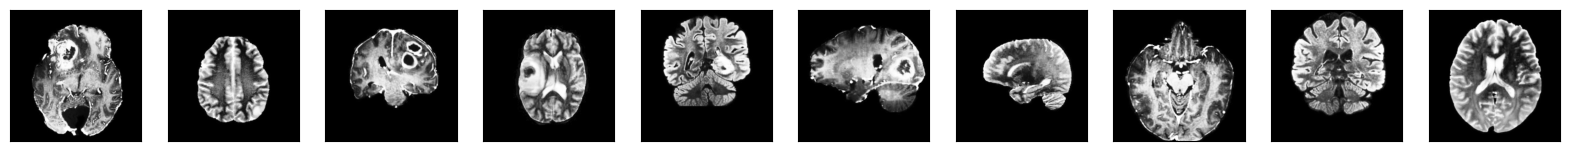

In [10]:
# def plot(x_train, p, labels=False):
#     plt.figure(figsize=(17, 14))
#     for i in range(150):
#         ax = plt.subplot(15,10, i + 1)
#         plt.imshow(x_train[i].reshape(256, 256), cmap='gray') 
#         plt.xticks([])
#         plt.yticks([])
#         plt.gray()
#         if labels:
#             plt.xlabel(np.argmax(p[i]))
#     plt.tight_layout()
#     plt.show() 
#     return 
# # plot(x_train, None) 
def plot(x_train, p , labels = False): 
    plt.figure(figsize = (20,2)) 
    for i in range(10): 
        ax=plt.subplot(1, 10, i+1) 
        plt.imshow(x_train[i].reshape(256,256)) 
        plt.xticks([]) 
        plt.yticks([]) 
        plt.gray()
        if labels: 
#             plt.xlabel(np.argmax(p[i])) 
            plt.show() 
    return 
plot(x_train, None) 

In [11]:
# def SRelu(x):
#     x = tf.where(x < 0, tf.zeros_like(x), x)
#     p = 0.05
#     p_hat = x
#     KL_divergence = p * (tf.math.log(p / p_hat)) + (1 - p) * (tf.math.log(1 - p / 1 - p_hat))
#     x = tf.where(x < KL_divergence, tf.zeros_like(x), x)
#     return x

In [13]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import layers
import tensorflow as tf
import keras
channels=1
# Assuming you have images with shape (height, width, channels)
input_image = Input(shape = (256,256,1)) 
print(input_image.shape)

x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(input_image)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation="relu", padding="same")(x)
decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = Model(input_image, decoded)
autoencoder.summary()

(None, 256, 256, 1)
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 1)]     0         
                                                                 
 conv2d_4 (Conv2D)           (None, 256, 256, 64)      640       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 128, 128, 64)     0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 128, 128, 32)      18464     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                             
                                                                 
 conv2d_transpose (Conv2DTra  (None, 128,

In [ ]:
# def dice_loss(y_true, y_pred):
#     smooth = 1.0
#     intersection = tf.reduce_sum(y_true * y_pred)
#     union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
#     dice_coef = (2.0 * intersection + smooth) / (union + smooth)
#     return 1.0 - dice_coef

In [ ]:
opt = keras.optimizers.Adam(learning_rate=0.001)
autoencoder.compile(loss= 'MSE' , optimizer ='adam',metrics=['accuracy']) 
# autoencoder.compile(loss= dice_loss , optimizer ='adam',metrics=['accuracy']) 

In [ ]:
# !conda install pynvml -c conda-forge --yes

In [ ]:
import pynvml
pynvml.nvmlInit()

In [ ]:
deviceCount = pynvml.nvmlDeviceGetCount()
for i in range(deviceCount):
    handle = pynvml.nvmlDeviceGetHandleByIndex(i)
    print(f"Device {i} {pynvml.nvmlDeviceGetName(handle).decode()}")

In [ ]:
from pynvml.smi import nvidia_smi
print(f"Free GPU memory - {nvidia_smi.getInstance().DeviceQuery('memory.total')}")
print(f"Used GPU memory - {nvidia_smi.getInstance().DeviceQuery('memory.used')}")

In [ ]:
import tensorflow as tf 
checkpointer = tf.keras.callbacks.ModelCheckpoint('/kaggle/working/model_for_PhaseOne-Twodatasets-P2.h5', verbose=1, save_best_only=True)
csv_logger = tf.keras.callbacks.CSVLogger('/kaggle/working.csv', separator=",", append=False)
callbacks = [tf.keras.callbacks.EarlyStopping(patience=14, monitor='val_loss'),tf.keras.callbacks.TensorBoard(log_dir='logs')]
history = autoencoder.fit(x_train_noisy, x_train, batch_size=14, epochs=10,callbacks=[checkpointer,csv_logger], shuffle = True, validation_data=(x_val_noisy, x_test))

In [ ]:
preds = autoencoder.predict(x_val_noisy)
print(preds.shape)
# plot(preds, None) 
# print("Denoised Image") 
plt.imshow(preds[28].reshape(256,256,1))

In [ ]:
plot(preds, None) 
print("Denoised Image") 
plt.imshow(preds[28].reshape(256,256,1))

In [ ]:
preds = preds.reshape((2935, 256, 256))

In [ ]:
import math

# Calculate RMSE
MSE = np.square(np.subtract(x_test, preds)).mean()
RMSE = math.sqrt(MSE)
print("Root Mean Squared Error:", RMSE)


In [ ]:
from math import log10, sqrt
import cv2
import numpy as np
  
def PSNR(x_test, preds):
    mse = np.mean((x_test - preds) ** 2)
    if(mse == 0):  # MSE is zero means no noise is present in the signal .
                  # Therefore PSNR have no importance.
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr
  
def main():
#      original = cv2.imread("original_image.png")
#      compressed = cv2.imread("compressed_image.png", 1)
     value = PSNR(x_test, preds)
     print(f"PSNR value is {value} dB")
       
if __name__ == "__main__":
    main()

In [ ]:
import tensorflow as tf
# Reshape the images to have a single channel if they are grayscale
img1 = tf.expand_dims(x_test, axis=-1)
img2 = tf.expand_dims(preds, axis=-1)

# Convert the image arrays to TensorFlow tensors
img1 = tf.convert_to_tensor(img1, dtype=tf.float32)
img2 = tf.convert_to_tensor(img2, dtype=tf.float32)

# Set the maximum pixel value
max_val = 1.0  # Assuming the pixel values are normalized between 0 and 1

# Define the power factors for multi-scale SSIM
power_factors = [0.0448, 0.2856, 0.3001, 0.2363, 0.1333]

# Calculate multi-scale SSIM
mul_ssim_score = tf.image.ssim_multiscale(
    img1,
    img2,
    max_val,
    power_factors=power_factors,
    filter_size=11,
    filter_sigma=1.5,
    k1=0.01,
    k2=0.03
)
ssim_score = tf.image.ssim(
    img1,
    img2,
    max_val
)

# Print the result
print("Multi-Scale SSIM:", np.mean(mul_ssim_score.numpy()))


In [ ]:
print("Single-Scale SSIM:", np.mean(ssim_score.numpy()))

In [ ]:
# import numpy as np

# def gaussian_kernel(X, Y, sigma):
#     X_sqnorm = np.sum(X ** 2, axis=1)
#     Y_sqnorm = np.sum(Y ** 2, axis=1)
#     dist = X_sqnorm[:, None] - 2.0 * np.dot(X, Y.T) + Y_sqnorm
#     kernel = np.exp(-dist / (2 * sigma ** 2))
#     return kernel

# def MMD(x, y, sigma, kernel="multiscale"):
#     """Emprical maximum mean discrepancy. The lower the result
#        the more evidence that distributions are the same.

#     Args:
#         x: first sample, distribution P
#         y: second sample, distribution Q
#         sigma: bandwidth for Gaussian kernel
#         kernel: kernel type such as "multiscale" or "rbf"
#     """
#     XX, YY, XY = (np.zeros((x.shape[0], x.shape[0])), np.zeros((y.shape[0], y.shape[0])), np.zeros((x.shape[0], y.shape[0])))

#     if kernel == "multiscale":
#         bandwidth_range = [0.2, 0.5, 0.9, 1.3]
#         for a in bandwidth_range:
#             K_XX = gaussian_kernel(x, x, a)
#             K_YY = gaussian_kernel(y, y, a)
#             K_XY = gaussian_kernel(x, y, a)

#             XX += a ** 2 * (a ** 2 + K_XX) ** -1
#             YY += a ** 2 * (a ** 2 + K_YY) ** -1
#             XY += a ** 2 * (a ** 2 + K_XY) ** -1

#     elif kernel == "rbf":
#         bandwidth_range = [10, 15, 20, 50]
#         for a in bandwidth_range:
#             K_XX = gaussian_kernel(x, x, a)
#             K_YY = gaussian_kernel(y, y, a)
#             K_XY = gaussian_kernel(x, y, a)

#             XX += np.exp(-0.5 * K_XX / a)
#             YY += np.exp(-0.5 * K_YY / a)
#             XY += np.exp(-0.5 * K_XY / a)

#     else:
#         raise ValueError("Unsupported kernel type. Use 'multiscale' or 'rbf'.")

#     n = x.shape[0]
#     m = y.shape[0]

#     return np.mean(XX + YY - 2. * XY)

# # Example usage

# sigma = 1.0
# kernel_type = "multiscale"  # Replace with "rbf" for the RBF kernel

# mmd_value = MMD(preds, x_test, sigma, kernel=kernel_type)
# print("MMD value:", mmd_value)

In [ ]:
# !pip install pyrfr

In [ ]:
# from pyRBF import mmd_kernel
# from scipy.interpolate import Rbf

# mmd_value = mmd_kernel(x_test, preds)
# print(f"MMD between x_test and preds: {mmd_value}")


In [ ]:
from IPython.display import FileLink
FileLink(r'/kaggle/working/model_for_PhaseOne-T2w-P2.h5')